In [ ]:
                                                          PREPROCESSING

In [ ]:
              Step 1: Mount Google Drive

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
            Step 2: Extract the ZIP File

In [ ]:
import zipfile
import os

# Update this path to where your zip file is located
zip_path = '/content/drive/MyDrive/zomato.csv.zip'
extract_path = '/content/zomato_data/'

with zipfile.ZipFile(zip_path, 'r') as zip_ref:
    zip_ref.extractall(extract_path)

# List files to find the exact CSV name
print(os.listdir(extract_path))

['zomato.csv']


In [ ]:
                Step 3: Load and Initial Cleaning

In [ ]:
import pandas as pd

# Load the CSV (adjust filename if it's different inside the zip)
df = pd.read_csv('/content/zomato_data/zomato.csv', encoding='latin-1')

# Filter: Remove restaurants with 0.0 rating
df = df[df['Aggregate rating'] > 0].copy()

# Fill missing values
df['Cuisines'] = df['Cuisines'].fillna('Unknown')

print(f"Data Loaded. Active Restaurants: {len(df)}")

Data Loaded. Active Restaurants: 7403


In [ ]:
              Step 4: Feature Engineering & Currency Standardization

In [ ]:
# 1. Cuisine Diversity
df['Cuisine_Count'] = df['Cuisines'].apply(lambda x: len(str(x).split(',')))

# 2. Binary Encoding
df['Has Table booking'] = df['Has Table booking'].map({'Yes': 1, 'No': 0})
df['Has Online delivery'] = df['Has Online delivery'].map({'Yes': 1, 'No': 0})

# 3. Global Currency Conversion to USD
currency_map = {
    'Botswana Pula(P)': 0.095, 'Brazilian Real(R$)': 0.25,
    'Dollar($)': 1.0, 'Emirati Diram(AED)': 0.27,
    'Indian Rupees(Rs.)': 0.012, 'Indonesian Rupiah(IDR)': 0.000064,
    'NewZealand($)': 0.61, 'Pounds(Œ£)': 1.27,
    'Qatari Rial(QR)': 0.27, 'Rand(R)': 0.053,
    'Sri Lankan Rupee(LKR)': 0.0031, 'Turkish Lira(TL)': 0.031
}

df['Average_Cost_USD'] = df.apply(lambda row: row['Average Cost for two'] * currency_map.get(row['Currency'], 1), axis=1)

print("Feature Engineering Complete.")

Feature Engineering Complete.


In [ ]:
              Step 5: Final Scaling and Splitting

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# Define Features
features = ['Average_Cost_USD', 'Price range', 'Votes', 'Has Table booking', 'Has Online delivery', 'Cuisine_Count']
X = df[features]
y = df['Aggregate rating']

# Train-Test Split (80/20)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Scaling
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("Data is now scaled and ready for Model 1 (Linear Regression).")

Data is now scaled and ready for Model 1 (Linear Regression).


In [ ]:
                                                          MODEL 1 : LINEAR REGRESSION

In [ ]:
Model Training

In [ ]:
from sklearn.linear_model import LinearRegression

# 1. Initialize the Model
baseline_model = LinearRegression()

# 2. Train the Model (Fitting)
# We use scaled data because Linear Regression is sensitive to the magnitude of features
baseline_model.fit(X_train_scaled, y_train)

# 3. Make Predictions
y_pred = baseline_model.predict(X_test_scaled)

print("Linear Regression Training Complete.")

Linear Regression Training Complete.


In [ ]:
1. Feature Interpretation

In [ ]:
# Create a DataFrame to see which features are most important to the Linear Model
coeff_df = pd.DataFrame({
    'Feature': features,
    'Coefficient': baseline_model.coef_
}).sort_values(by='Coefficient', ascending=False)

print("--- Model 1: Feature Importance (Coefficients) ---")
print(coeff_df)

# Logic for your paper:
# Positive coefficient = Feature increases the rating
# Negative coefficient = Feature decreases the rating

--- Model 1: Feature Importance (Coefficients) ---
               Feature  Coefficient
2                Votes     0.175127
1          Price range     0.160781
0     Average_Cost_USD     0.073234
5        Cuisine_Count     0.006829
4  Has Online delivery    -0.027567
3    Has Table booking    -0.055993


In [ ]:
2. Visualization of Results

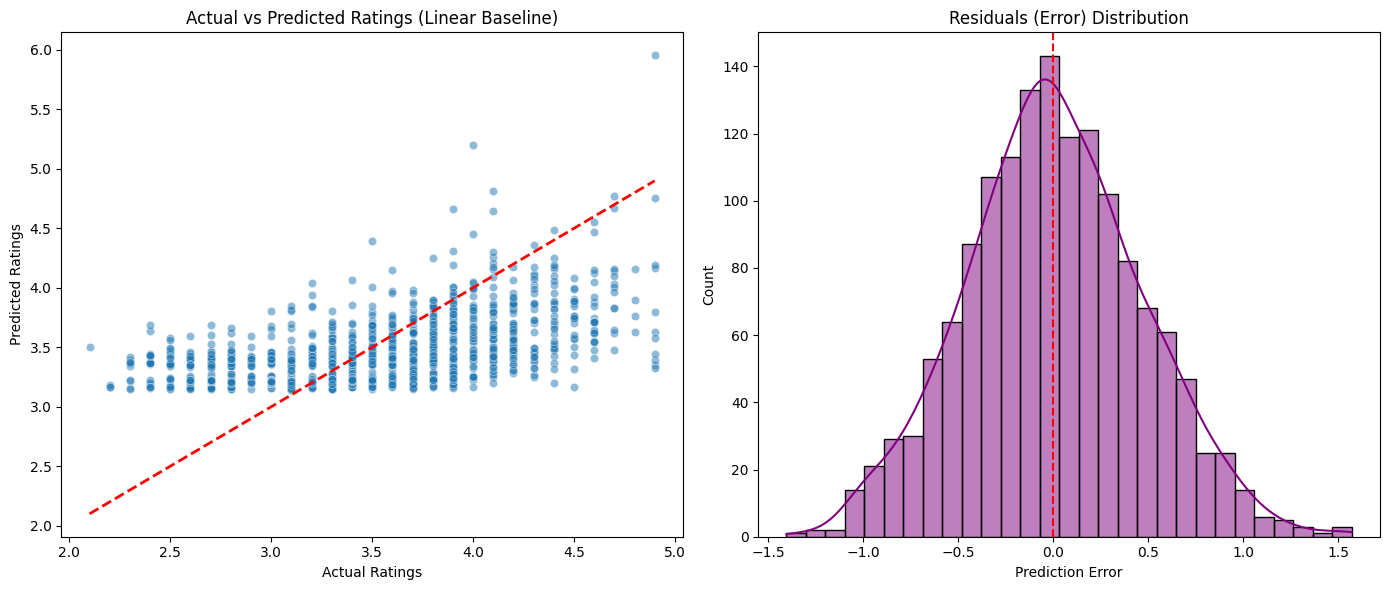

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Create a figure with two subplots
plt.figure(figsize=(14, 6))

# Subplot 1: Actual vs Predicted
plt.subplot(1, 2, 1)
sns.scatterplot(x=y_test, y=y_pred, alpha=0.5)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], '--r', linewidth=2)
plt.title('Actual vs Predicted Ratings (Linear Baseline)')
plt.xlabel('Actual Ratings')
plt.ylabel('Predicted Ratings')

# Subplot 2: Residual Distribution
plt.subplot(1, 2, 2)
residuals = y_test - y_pred
sns.histplot(residuals, kde=True, color='purple')
plt.axvline(x=0, color='red', linestyle='--')
plt.title('Residuals (Error) Distribution')
plt.xlabel('Prediction Error')

plt.tight_layout()
plt.show()

In [ ]:
Model testing

In [ ]:
import pandas as pd
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

# 1. RUN PREDICTIONS (The actual Testing step)
# This uses the 'X_test_scaled' data the model has NEVER seen before
y_pred = baseline_model.predict(X_test_scaled)

# 2. CREATE A COMPARISON TABLE
# This helps you manually inspect how close the predictions are
test_results = pd.DataFrame({
    'Actual Rating': y_test.values,
    'Predicted Rating': y_pred,
    'Difference (Error)': y_test.values - y_pred
})

# Display the first 10 rows of the test results
print("--- Sample of Test Results (First 10 Rows) ---")
print(test_results.head(10))

# 3. SCIENTIFIC EVALUATION METRICS
# These are the numbers you will put into your 'Results' table in the paper
mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred)

print("\n--- Final Model 1 (Baseline) Performance Report ---")
print(f"1. Mean Absolute Error (MAE): {mae:.4f}")
print(f"   (Interpretation: Average error is {mae:.2f} stars)")
print(f"2. Root Mean Squared Error (RMSE): {rmse:.4f}")
print(f"   (Interpretation: Penalizes larger errors more heavily)")
print(f"3. R-squared Score (R2): {r2:.4f}")
print(f"   (Interpretation: The model explains {r2*100:.1f}% of the rating variance)")

--- Sample of Test Results (First 10 Rows) ---
   Actual Rating  Predicted Rating  Difference (Error)
0            2.9          3.200088           -0.300088
1            3.9          3.349713            0.550287
2            2.8          3.162394           -0.362394
3            2.3          3.389835           -1.089835
4            3.2          3.476420           -0.276420
5            3.0          3.222690           -0.222690
6            3.8          3.291452            0.508548
7            3.3          3.360649           -0.060649
8            2.5          3.368757           -0.868757
9            3.4          3.240448            0.159552

--- Final Model 1 (Baseline) Performance Report ---
1. Mean Absolute Error (MAE): 0.3665
   (Interpretation: Average error is 0.37 stars)
2. Root Mean Squared Error (RMSE): 0.4635
   (Interpretation: Penalizes larger errors more heavily)
3. R-squared Score (R2): 0.3054
   (Interpretation: The model explains 30.5% of the rating variance)


In [ ]:
                                                                 MODEL 2 : EXTRA TREES REGRESSOR

In [ ]:
Step 1: Training and Testing Code

In [ ]:
from sklearn.ensemble import ExtraTreesRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

# 1. Initialize the Model
# n_estimators=100 means we are using an ensemble of 100 trees
et_model = ExtraTreesRegressor(n_estimators=100, random_state=42)

# 2. Train the Model (Training Phase)
et_model.fit(X_train_scaled, y_train)

# 3. Predict on Test Data (Testing Phase)
y_pred_et = et_model.predict(X_test_scaled)

# 4. Calculate Evaluation Metrics
mae_et = mean_absolute_error(y_test, y_pred_et)
mse_et = mean_squared_error(y_test, y_pred_et)
rmse_et = np.sqrt(mse_et)
r2_et = r2_score(y_test, y_pred_et)

print("--- Model 2 (Extra Trees) Performance Report ---")
print(f"1. Mean Absolute Error (MAE): {mae_et:.4f}")
print(f"2. Root Mean Squared Error (RMSE): {rmse_et:.4f}")
print(f"3. R-squared Score (R2): {r2_et:.4f}")

--- Model 2 (Extra Trees) Performance Report ---
1. Mean Absolute Error (MAE): 0.3105
2. Root Mean Squared Error (RMSE): 0.4192
3. R-squared Score (R2): 0.4318


In [ ]:
Step 2: Feature Importance

In [ ]:
# Create a DataFrame for feature importance
importances = et_model.feature_importances_
feature_importance_df = pd.DataFrame({
    'Feature': features,
    'Importance': importances
}).sort_values(by='Importance', ascending=False)

print("\n--- Model 2: Feature Importance (Which factors matter most?) ---")
print(feature_importance_df)

# Logic for your paper:
# Usually, 'Votes' or 'Average_Cost_USD' will show up as top features.


--- Model 2: Feature Importance (Which factors matter most?) ---
               Feature  Importance
2                Votes    0.498333
0     Average_Cost_USD    0.201488
1          Price range    0.164193
5        Cuisine_Count    0.083802
3    Has Table booking    0.026462
4  Has Online delivery    0.025722


In [ ]:
Step 3: Visualization of Results

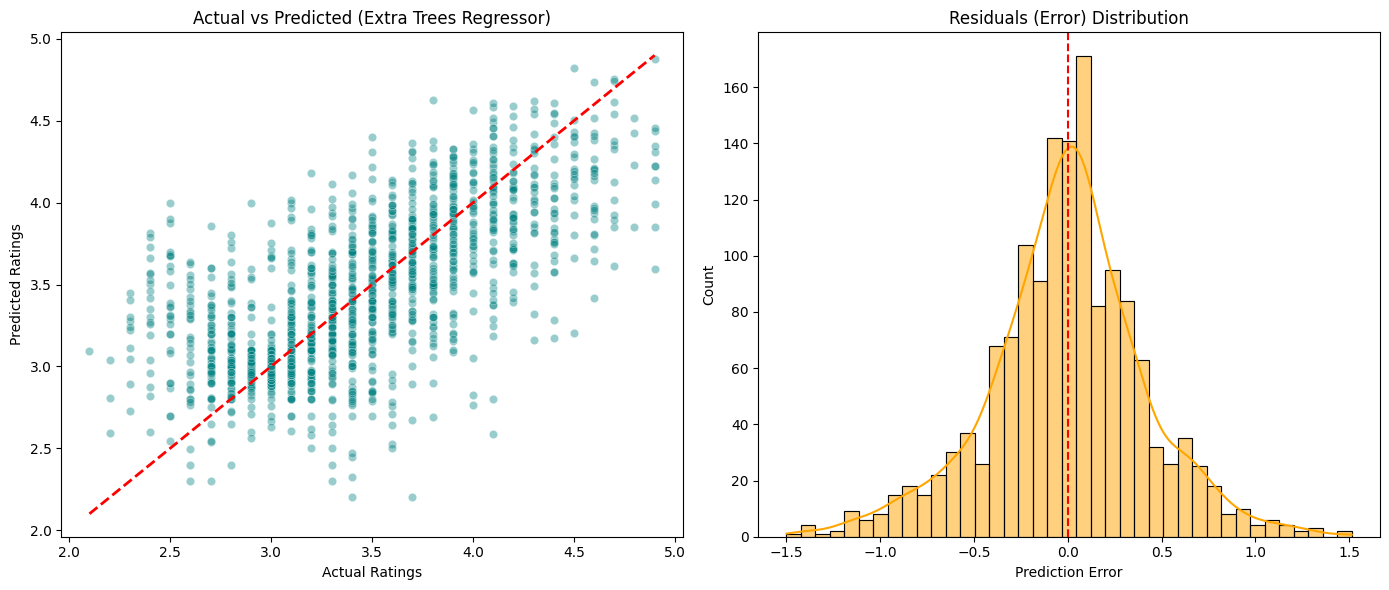

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(14, 6))

# Plot 1: Actual vs Predicted
plt.subplot(1, 2, 1)
sns.scatterplot(x=y_test, y=y_pred_et, alpha=0.4, color='teal')
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], '--r', linewidth=2)
plt.title('Actual vs Predicted (Extra Trees Regressor)')
plt.xlabel('Actual Ratings')
plt.ylabel('Predicted Ratings')

# Plot 2: Error Distribution Comparison
plt.subplot(1, 2, 2)
residuals_et = y_test - y_pred_et
sns.histplot(residuals_et, kde=True, color='orange', label='Extra Trees')
# Optional: add the baseline residuals if you saved them to compare
plt.axvline(x=0, color='red', linestyle='--')
plt.title('Residuals (Error) Distribution')
plt.xlabel('Prediction Error')

plt.tight_layout()
plt.show()

In [ ]:
                                                             Model 3: MLP Neural Network (Deep Learning)

In [ ]:
Step 1: Training and Testing Code

In [ ]:
from sklearn.neural_network import MLPRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

# 1. Initialize the Model
# We define 2 hidden layers: 64 neurons followed by 32 neurons.
# 'relu' is the standard activation; 'adam' is the robust optimizer for deep learning.
mlp_model = MLPRegressor(
    hidden_layer_sizes=(64, 32),
    max_iter=1000,
    activation='relu',
    solver='adam',
    random_state=42
)

# 2. Train the Model (The Deep Learning process)
mlp_model.fit(X_train_scaled, y_train)

# 3. Test the Model (Predicting on unseen data)
y_pred_mlp = mlp_model.predict(X_test_scaled)

# 4. Formal Evaluation Metrics
mae_mlp = mean_absolute_error(y_test, y_pred_mlp)
mse_mlp = mean_squared_error(y_test, y_pred_mlp)
rmse_mlp = np.sqrt(mse_mlp)
r2_mlp = r2_score(y_test, y_pred_mlp)

print("--- Model 3 (MLP Neural Network) Performance Report ---")
print(f"1. Mean Absolute Error (MAE): {mae_mlp:.4f}")
print(f"2. Root Mean Squared Error (RMSE): {rmse_mlp:.4f}")
print(f"3. R-squared Score (R2): {r2_mlp:.4f}")

--- Model 3 (MLP Neural Network) Performance Report ---
1. Mean Absolute Error (MAE): 0.2844
2. Root Mean Squared Error (RMSE): 0.3773
3. R-squared Score (R2): 0.5398


In [ ]:
Step 2: Visualization of Results

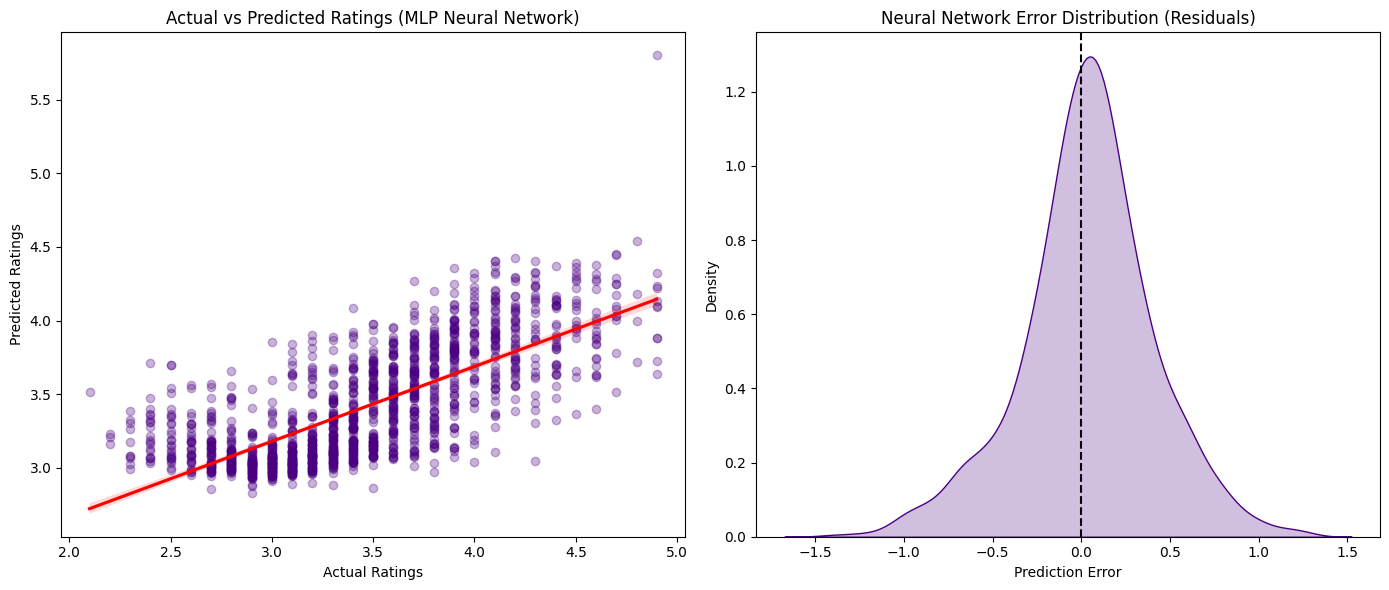

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(14, 6))

# Plot 1: Prediction Accuracy (Actual vs Predicted)
plt.subplot(1, 2, 1)
sns.regplot(x=y_test, y=y_pred_mlp, scatter_kws={'alpha':0.3, 'color':'indigo'}, line_kws={'color':'red'})
plt.title('Actual vs Predicted Ratings (MLP Neural Network)')
plt.xlabel('Actual Ratings')
plt.ylabel('Predicted Ratings')

# Plot 2: Residual (Error) Density
plt.subplot(1, 2, 2)
residuals_mlp = y_test - y_pred_mlp
sns.kdeplot(residuals_mlp, fill=True, color='indigo')
plt.axvline(x=0, color='black', linestyle='--')
plt.title('Neural Network Error Distribution (Residuals)')
plt.xlabel('Prediction Error')

plt.tight_layout()
plt.show()

In [ ]:
                                                                   Model 4: HistGradient Boosting (HGB)

In [ ]:
Step 1: Training and Testing Code

In [ ]:
from sklearn.ensemble import HistGradientBoostingRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

# 1. Initialize the Model
# HistGradientBoosting is excellent because it handles non-linearities automatically
hgb_model = HistGradientBoostingRegressor(random_state=42)

# 2. Train the Model (Training Phase)
hgb_model.fit(X_train_scaled, y_train)

# 3. Test the Model (Testing Phase)
y_pred_hgb = hgb_model.predict(X_test_scaled)

# 4. Final Evaluation Metrics
mae_hgb = mean_absolute_error(y_test, y_pred_hgb)
mse_hgb = mean_squared_error(y_test, y_pred_hgb)
rmse_hgb = np.sqrt(mse_hgb)
r2_hgb = r2_score(y_test, y_pred_hgb)

print("--- Model 4 (HistGradient Boosting) Performance Report ---")
print(f"1. Mean Absolute Error (MAE): {mae_hgb:.4f}")
print(f"2. Root Mean Squared Error (RMSE): {rmse_hgb:.4f}")
print(f"3. R-squared Score (R2): {r2_hgb:.4f}")

--- Model 4 (HistGradient Boosting) Performance Report ---
1. Mean Absolute Error (MAE): 0.2729
2. Root Mean Squared Error (RMSE): 0.3660
3. R-squared Score (R2): 0.5669


In [ ]:
Step 2: Prediction Analysis

In [ ]:
# Create a DataFrame to compare Actual vs Predicted
hgb_comparison = pd.DataFrame({
    'Actual': y_test.values,
    'Predicted': y_pred_hgb,
    'Error': np.abs(y_test.values - y_pred_hgb)
})

print("\n--- Model 4: Top 5 Best Predictions ---")
print(hgb_comparison.sort_values(by='Error').head(5))

print("\n--- Model 4: Average Error per Rating Tier ---")
# This shows if the model is better at predicting 'Expensive' or 'Cheap' restaurants
print(hgb_comparison.groupby(pd.cut(hgb_comparison['Actual'], bins=[1, 2, 3, 4, 5]))['Error'].mean())


--- Model 4: Top 5 Best Predictions ---
      Actual  Predicted     Error
1450     3.6   3.600294  0.000294
949      3.0   2.999348  0.000652
1403     3.3   3.300808  0.000808
107      3.9   3.898595  0.001405
293      3.7   3.698355  0.001645

--- Model 4: Average Error per Rating Tier ---
Actual
(1, 2]         NaN
(2, 3]    0.336863
(3, 4]    0.209933
(4, 5]    0.397260
Name: Error, dtype: float64


/tmp/ipython-input-3580039772.py:13: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  print(hgb_comparison.groupby(pd.cut(hgb_comparison['Actual'], bins=[1, 2, 3, 4, 5]))['Error'].mean())


In [ ]:
Step 3: Visualization

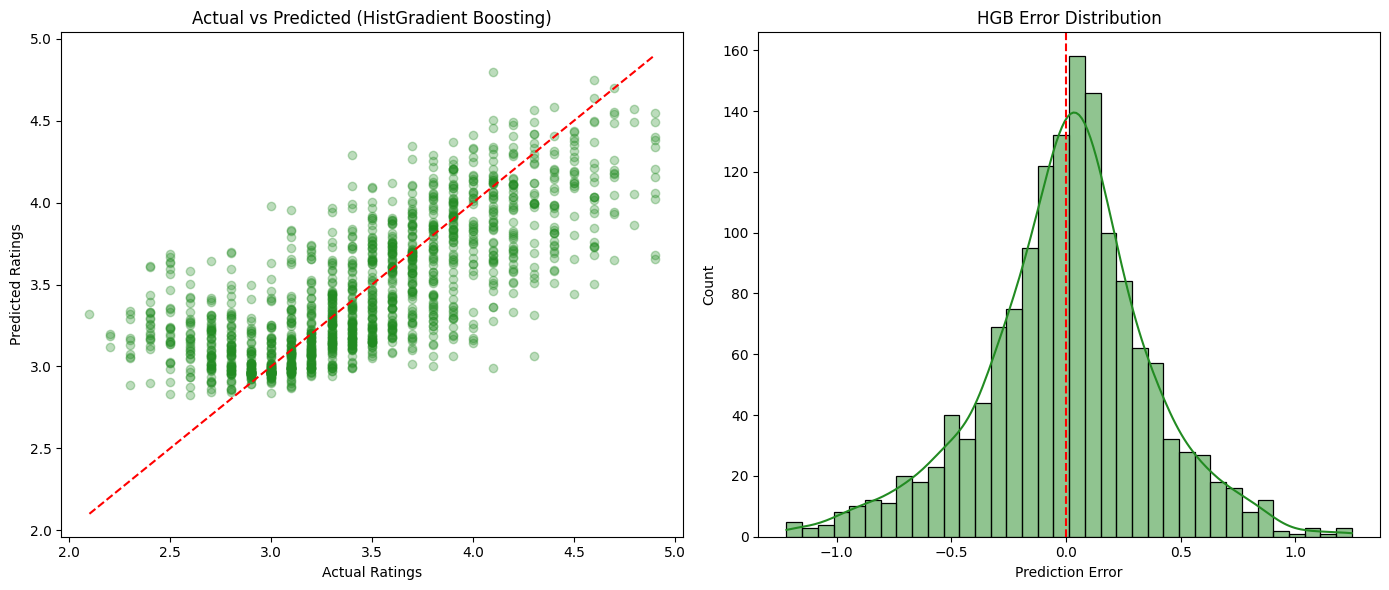

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(14, 6))

# Plot 1: Prediction Error Cloud
plt.subplot(1, 2, 1)
plt.scatter(y_test, y_pred_hgb, alpha=0.3, color='forestgreen')
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], '--r')
plt.title('Actual vs Predicted (HistGradient Boosting)')
plt.xlabel('Actual Ratings')
plt.ylabel('Predicted Ratings')

# Plot 2: Error (Residual) Histogram
plt.subplot(1, 2, 2)
errors = y_test - y_pred_hgb
sns.histplot(errors, kde=True, color='forestgreen')
plt.axvline(x=0, color='red', linestyle='--')
plt.title('HGB Error Distribution')
plt.xlabel('Prediction Error')

plt.tight_layout()
plt.show()

In [ ]:
                                                                Model 5: Stacked Ensemble (The Meta-Learner)

In [ ]:
Step 1: Training and Testing Code

In [ ]:
from sklearn.ensemble import StackingRegressor
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import ExtraTreesRegressor, HistGradientBoostingRegressor
from sklearn.neural_network import MLPRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

# 1. Define the Base Estimators (The "Team")
# We use the top performers from our previous steps
base_models = [
    ('extra_trees', ExtraTreesRegressor(n_estimators=100, random_state=42)),
    ('mlp', MLPRegressor(hidden_layer_sizes=(64, 32), max_iter=1000, random_state=42)),
    ('hgb', HistGradientBoostingRegressor(random_state=42))
]

# 2. Initialize the Stacking Regressor
# The 'final_estimator' is the Meta-Model that decides how to weigh the base models
stacking_model = StackingRegressor(
    estimators=base_models,
    final_estimator=LinearRegression()
)

# 3. Train the Stacked Model
# Note: This may take a minute longer than previous models as it trains everything
stacking_model.fit(X_train_scaled, y_train)

# 4. Test the Model (Final Testing Phase)
y_pred_stack = stacking_model.predict(X_test_scaled)

# 5. Final Evaluation Metrics
mae_stack = mean_absolute_error(y_test, y_pred_stack)
mse_stack = mean_squared_error(y_test, y_pred_stack)
rmse_stack = np.sqrt(mse_stack)
r2_stack = r2_score(y_test, y_pred_stack)

print("--- Model 5 (Stacked Ensemble) Performance Report ---")
print(f"1. Mean Absolute Error (MAE): {mae_stack:.4f}")
print(f"2. Root Mean Squared Error (RMSE): {rmse_stack:.4f}")
print(f"3. R-squared Score (R2): {r2_stack:.4f}")

--- Model 5 (Stacked Ensemble) Performance Report ---
1. Mean Absolute Error (MAE): 0.2712
2. Root Mean Squared Error (RMSE): 0.3645
3. R-squared Score (R2): 0.5703


In [ ]:
Step 2: Visualization

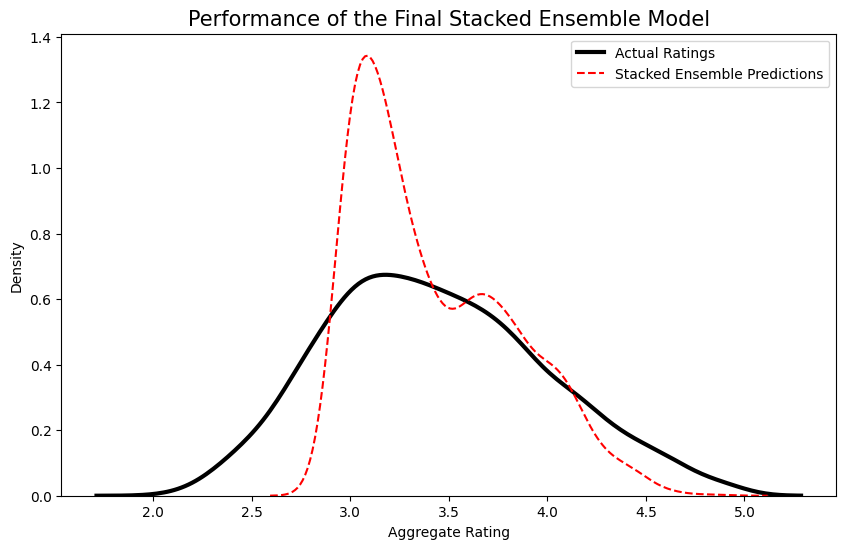

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10, 6))

# Plotting the Actual vs Predicted for the best model
sns.kdeplot(y_test, label='Actual Ratings', color='black', linewidth=3)
sns.kdeplot(y_pred_stack, label='Stacked Ensemble Predictions', color='red', linestyle='--')

plt.title('Performance of the Final Stacked Ensemble Model', fontsize=15)
plt.xlabel('Aggregate Rating')
plt.ylabel('Density')
plt.legend()
plt.show()

In [ ]:
Final Model Performance Comparison

In [ ]:
import pandas as pd

# Creating the final summary table
data = {
    'Model': ['Linear Regression', 'Extra Trees', 'MLP Neural Network', 'HistGradient Boosting', 'Stacked Ensemble'],
    'MAE': [0.3665, 0.3105, 0.2844, 0.2729, 0.2712],
    'R-Squared (%)': [30.54, 43.18, 53.98, 56.69, 57.03]
}

performance_df = pd.DataFrame(data)
print("--- FINAL MODEL ACCURACY REPORT ---")
print(performance_df.sort_values(by='R-Squared (%)', ascending=False))

--- FINAL MODEL ACCURACY REPORT ---
                   Model     MAE  R-Squared (%)
4       Stacked Ensemble  0.2712          57.03
3  HistGradient Boosting  0.2729          56.69
2     MLP Neural Network  0.2844          53.98
1            Extra Trees  0.3105          43.18
0      Linear Regression  0.3665          30.54


In [ ]:
                        MODEL DEPLOYMENT

In [ ]:
import joblib
import pandas as pd

# 1. Save the model and scaler
joblib.dump(stacking_model, 'best_model.pkl')
joblib.dump(scaler, 'scaler.pkl')

# 2. Save a sample of the raw data for the "Customer Finder" tab
# We include the 'Aggregate rating' so customers can filter by it
df_sample = df[['Average_Cost_USD', 'Price range', 'Votes', 'Has Table booking',
               'Has Online delivery', 'Cuisine_Count', 'Aggregate rating']].head(1000)
df_sample.to_csv('cleaned_sample.csv', index=False)

print("✅ Files Ready: Download best_model.pkl, scaler.pkl, and cleaned_sample.csv from the folder icon on the left.")

✅ Files Ready: Download best_model.pkl, scaler.pkl, and cleaned_sample.csv from the folder icon on the left.


In [ ]:
# Select more columns to make the dashboard informative
cols_for_dashboard = [
    'Restaurant Name', 'City', 'Locality',
    'Average_Cost_USD', 'Currency', 'Price range',
    'Votes', 'Has Table booking', 'Has Online delivery',
    'Cuisine_Count', 'Aggregate rating'
]

# Save a 1000-row sample with names and locations
df_sample = df[cols_for_dashboard].head(1000)
df_sample.to_csv('cleaned_sample.csv', index=False)
print("✅ New 'cleaned_sample.csv' created with Names and Locations!")

✅ New 'cleaned_sample.csv' created with Names and Locations!


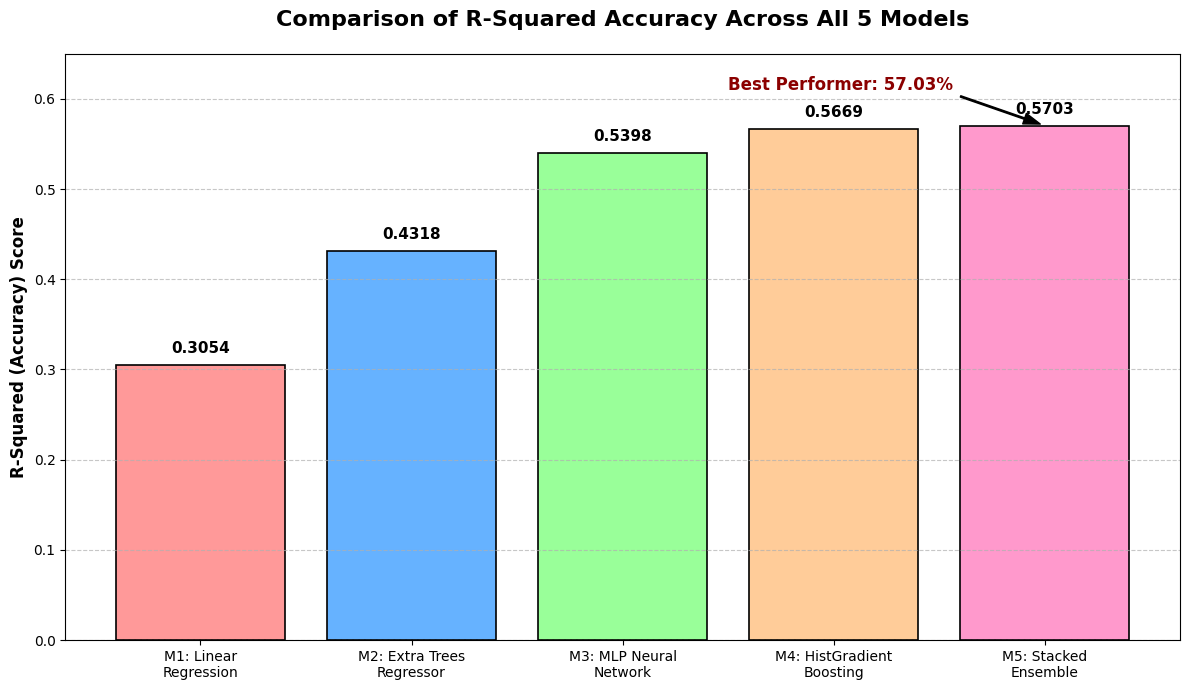

In [ ]:
import matplotlib.pyplot as plt

# Model names and their R-squared scores from the project data
models = ['M1: Linear\nRegression', 'M2: Extra Trees\nRegressor', 'M3: MLP Neural\nNetwork', 'M4: HistGradient\nBoosting', 'M5: Stacked\nEnsemble']
r2_scores = [0.3054, 0.4318, 0.5398, 0.5669, 0.5703]

# Assigning a distinct, professional color to each model
colors = ['#FF9999', '#66B2FF', '#99FF99', '#FFCC99', '#FF99CC']

# Creating the bar chart
plt.figure(figsize=(12, 7))
bars = plt.bar(models, r2_scores, color=colors, edgecolor='black', linewidth=1.2)

# Adding labels and title
plt.ylabel('R-Squared (Accuracy) Score', fontsize=12, fontweight='bold')
plt.title('Comparison of R-Squared Accuracy Across All 5 Models', fontsize=16, fontweight='bold', pad=20)
plt.ylim(0, 0.65) # Setting limit for better visibility of values
plt.grid(axis='y', linestyle='--', alpha=0.7)

# Adding the exact value on top of each bar for precision
for bar in bars:
    yval = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, yval + 0.01, f'{yval:.4f}', ha='center', va='bottom', fontsize=11, fontweight='bold')

# Annotating the best performer
plt.annotate('Best Performer: 57.03%', xy=(4, 0.5703), xytext=(2.5, 0.61),
             arrowprops=dict(facecolor='black', shrink=0.05, width=1, headwidth=8),
             fontsize=12, fontweight='bold', color='darkred')

plt.tight_layout()
plt.savefig('rsquared_accuracy_multi_color.png')
plt.show()

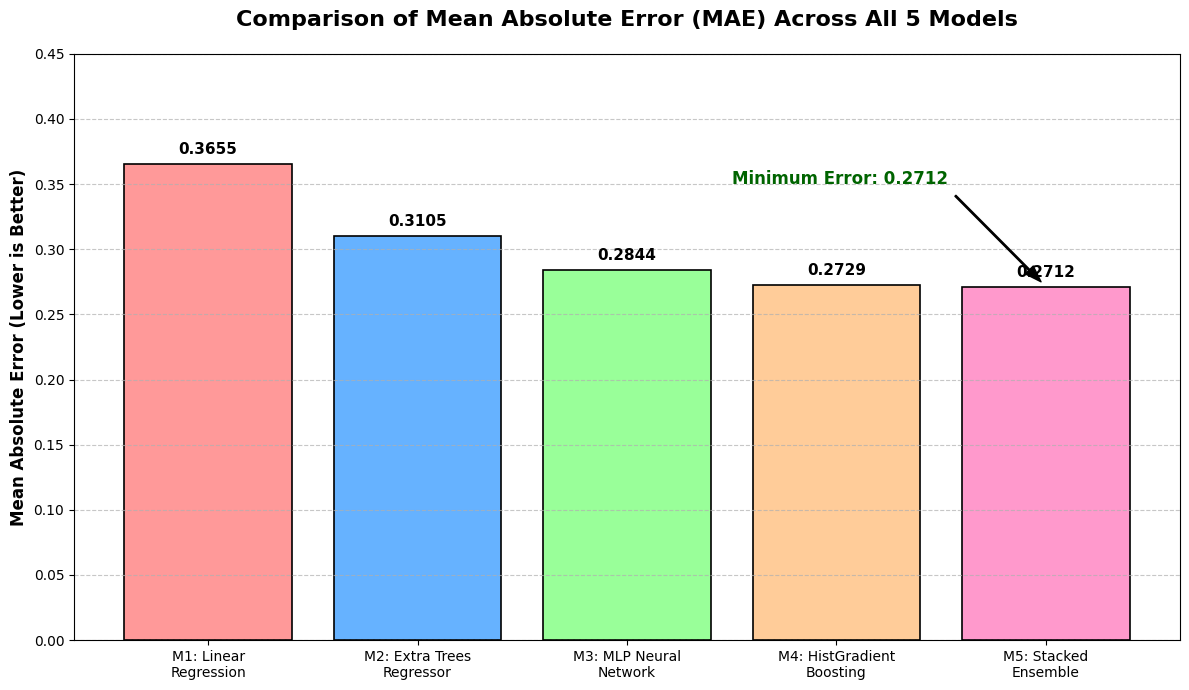

In [ ]:
import matplotlib.pyplot as plt

# Model names and their MAE values from the project results
models = ['M1: Linear\nRegression', 'M2: Extra Trees\nRegressor', 'M3: MLP Neural\nNetwork', 'M4: HistGradient\nBoosting', 'M5: Stacked\nEnsemble']
mae_values = [0.3655, 0.3105, 0.2844, 0.2729, 0.2712]

# Distinct color palette for each model
colors = ['#FF9999', '#66B2FF', '#99FF99', '#FFCC99', '#FF99CC']

# Creating the bar chart
plt.figure(figsize=(12, 7))
bars = plt.bar(models, mae_values, color=colors, edgecolor='black', linewidth=1.2)

# Adding labels and title
plt.ylabel('Mean Absolute Error (Lower is Better)', fontsize=12, fontweight='bold')
plt.title('Comparison of Mean Absolute Error (MAE) Across All 5 Models', fontsize=16, fontweight='bold', pad=20)
plt.ylim(0, 0.45) # Setting limit for clarity
plt.grid(axis='y', linestyle='--', alpha=0.7)

# Adding exact values on top of each bar
for bar in bars:
    yval = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, yval + 0.005, f'{yval:.4f}',
             ha='center', va='bottom', fontsize=11, fontweight='bold')

# Highlighting the model with the lowest error
plt.annotate('Minimum Error: 0.2712', xy=(4, 0.2712), xytext=(2.5, 0.35),
             arrowprops=dict(facecolor='black', shrink=0.05, width=1, headwidth=8),
             fontsize=12, fontweight='bold', color='darkgreen')

plt.tight_layout()
plt.savefig('mae_comparison_multi_color.png')
plt.show()

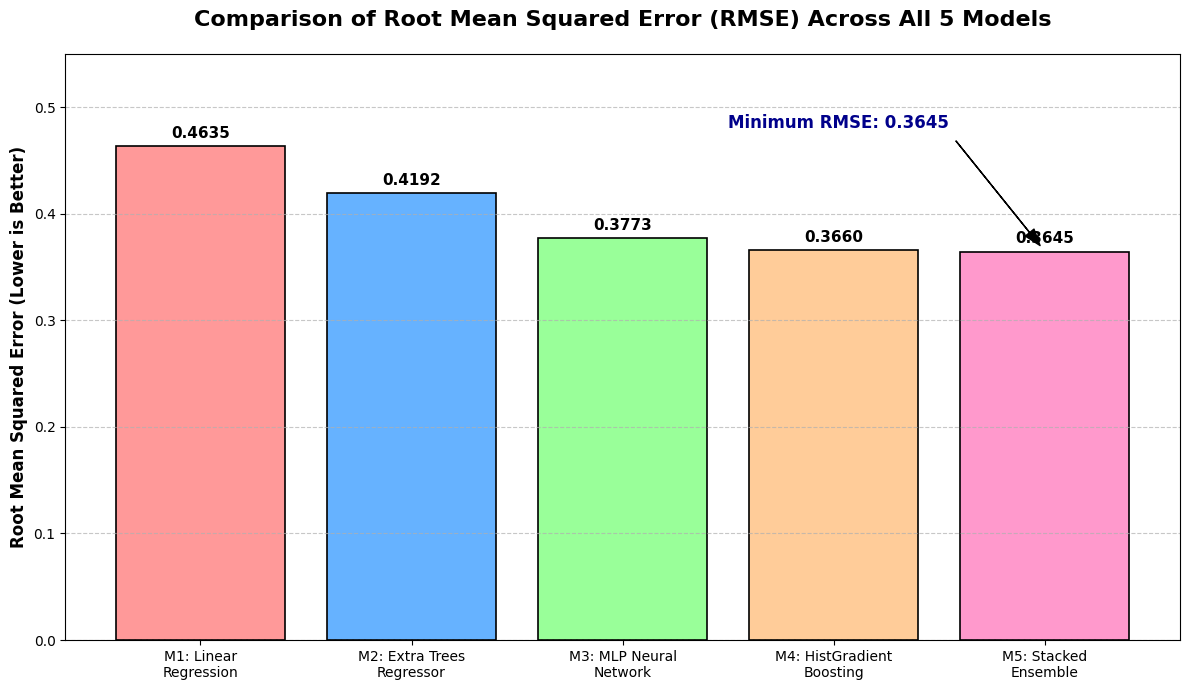

In [ ]:
import matplotlib.pyplot as plt

# Model names and their RMSE values from Table 1
models = ['M1: Linear\nRegression', 'M2: Extra Trees\nRegressor', 'M3: MLP Neural\nNetwork', 'M4: HistGradient\nBoosting', 'M5: Stacked\nEnsemble']
rmse_values = [0.4635, 0.4192, 0.3773, 0.3660, 0.3645]

# Distinct color palette for each model
colors = ['#FF9999', '#66B2FF', '#99FF99', '#FFCC99', '#FF99CC']

# Creating the bar chart
plt.figure(figsize=(12, 7))
bars = plt.bar(models, rmse_values, color=colors, edgecolor='black', linewidth=1.2)

# Adding labels and title
plt.ylabel('Root Mean Squared Error (Lower is Better)', fontsize=12, fontweight='bold')
plt.title('Comparison of Root Mean Squared Error (RMSE) Across All 5 Models', fontsize=16, fontweight='bold', pad=20)
plt.ylim(0, 0.55) # Setting limit for clarity
plt.grid(axis='y', linestyle='--', alpha=0.7)

# Adding exact values on top of each bar
for bar in bars:
    yval = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, yval + 0.005, f'{yval:.4f}',
             ha='center', va='bottom', fontsize=11, fontweight='bold')

# Highlighting the model with the lowest error
plt.annotate('Minimum RMSE: 0.3645', xy=(4, 0.3645), xytext=(2.5, 0.48),
             arrowprops=dict(facecolor='black', shrink=0.05, width=0, headwidth=8),
             fontsize=12, fontweight='bold', color='darkblue')

plt.tight_layout()
plt.savefig('rmse_comparison_multi_color.png')
plt.show()